# XGBoost Training for PTM Prediction

This notebook trains XGBoost models for multi-label classification of protein post-translational modifications.

## Overview
- **Task**: Multi-label binary classification (3 labels)
- **Model**: XGBoost with scale_pos_weight for class imbalance
- **Challenge**: Severe class imbalance (1:7 to 1:25 ratios)
- **Solution**: `scale_pos_weight` parameter to handle imbalance

## XGBoost vs Random Forest

**Why XGBoost often outperforms RF:**
- **Gradient boosting**: Builds trees sequentially, each correcting previous errors
- **Regularization**: Built-in L1/L2 regularization prevents overfitting
- **Better handling of imbalance**: scale_pos_weight parameter
- **Faster training**: More efficient tree construction
- **Usually 2-5% better F1/AUC** than Random Forest

## Labels to Predict:
1. S-glutathionylation (very rare: ~5% positive)
2. S-nitrosylation (rare: ~12% positive)
3. S-palmitoylation (very rare: ~3% positive)

## 1. Configuration

Set encoding method and hyperparameters for XGBoost.

In [25]:
# ============================================================================
# CONFIGURATION PARAMETERS
# ============================================================================

# Encoding method (change this to test different encodings)
ENCODING_MTHD = "onehot"  # Options: onehot, blosum, aapc, hybrid

# File paths
TRAIN_CSV_PATH = f"../data_engineered/{ENCODING_MTHD}/train_with_features_{ENCODING_MTHD}_split.csv"
VAL_CSV_PATH = f"../data_engineered/{ENCODING_MTHD}/val_with_features_{ENCODING_MTHD}_split.csv"
OUTPUT_DIR = f"../output/xgb/{ENCODING_MTHD}"

# XGBoost hyperparameters
N_ESTIMATORS = 300          # Number of boosting rounds
MAX_DEPTH = 6               # Maximum tree depth (controls overfitting)
LEARNING_RATE = 0.1         # Step size shrinkage (lower = more conservative)
SUBSAMPLE = 0.8             # Fraction of samples used per tree
COLSAMPLE_BYTREE = 0.8      # Fraction of features used per tree

# Computing resources
N_CORES = 16                # Number of CPU cores to use

print("Configuration loaded:")
print(f"  Encoding: {ENCODING_MTHD}")
print(f"  Train: {TRAIN_CSV_PATH}")
print(f"  Val: {VAL_CSV_PATH}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  n_estimators: {N_ESTIMATORS}")
print(f"  max_depth: {MAX_DEPTH}")
print(f"  learning_rate: {LEARNING_RATE}")

Configuration loaded:
  Encoding: onehot
  Train: ../data_engineered/onehot/train_with_features_onehot_split.csv
  Val: ../data_engineered/onehot/val_with_features_onehot_split.csv
  Output: ../output/xgb/onehot
  n_estimators: 300
  max_depth: 6
  learning_rate: 0.1


## 2. Set Environment Variables

Configure multi-threading before importing libraries.

In [26]:
import os

N_CORES = 16
# 1. Set Environment Variables (Must be done BEFORE importing sklearn/numpy)
os.environ["OMP_NUM_THREADS"] = str(N_CORES)
os.environ["MKL_NUM_THREADS"] = str(N_CORES)
os.environ["OPENBLAS_NUM_THREADS"] = str(N_CORES)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_CORES)
os.environ["NUMEXPR_NUM_THREADS"] = str(N_CORES)

## 3. Import Libraries

In [27]:
# Standard libraries
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

# Machine learning
import xgboost as xgb
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    roc_auc_score, 
    hamming_loss,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 4. Load Data

We load the pre-split training and validation data created by `04_train_val_split.py`.

**Important:** Everyone on the team should use the SAME split files for fair comparison!

In [28]:
# Load train/validation splits
train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)

print(f"Training samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"\nDataset shape: {train_df.shape}")

# Show first few rows
train_df.head()

Training samples: 71,208
Validation samples: 17,802

Dataset shape: (71208, 116)


,ID,Sequence,S-glutathionylation,S-nitrosylation,S-palmitoylation,aa_A,aa_C,aa_D,aa_E,aa_F,...,cys_ctx_2_M,cys_ctx_2_N,cys_ctx_2_P,cys_ctx_2_Q,cys_ctx_2_R,cys_ctx_2_S,cys_ctx_2_T,cys_ctx_2_V,cys_ctx_2_W,cys_ctx_2_Y
0,Q9Y6R7,ANCPLSCPANSRYELCGPACPTSCNGAAAPS,0,0,0,0.193548,0.161290,0.000000,0.032258,0.000000,...,False,False,False,False,False,False,False,False,False,False
1,O94903,PNPDFQLLLSLREELCKKLNIPADQVELSMG,0,0,0,0.032258,0.032258,0.064516,0.096774,0.032258,...,False,False,False,False,False,False,False,False,False,False
2,P10833,VSDYDPTIEDSYTKICTVDGIPARLDILDTA,0,1,1,0.064516,0.032258,0.193548,0.032258,0.000000,...,False,False,False,False,False,False,False,True,False,False
3,Q8K2Y7,AACSLVNPKDAAHSGCRSSLSLLHKNTPHVT,0,0,0,0.129032,0.064516,0.032258,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
4,Q9DBA8,PNAYCFSMPMVMHLACVNMRMSMPEALAAAT,0,0,0,0.193548,0.064516,0.000000,0.032258,0.032258,...,False,False,False,False,False,True,False,False,False,False


## 5. Prepare Features and Labels

### Key Steps:
1. Separate features from labels
2. Remove metadata columns (ID, Sequence)
3. **Convert boolean columns to integers** (sklearn requirement)
4. **Remove any non-numeric columns** (prevents errors)
5. Ensure all data is float type

In [29]:
# Define label columns (what we're predicting)
label_cols = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']

# Get feature columns (everything except ID, Sequence, and labels)
feature_cols = [col for col in train_df.columns 
                if col not in ['ID', 'Sequence'] + label_cols]

print(f"Total feature columns: {len(feature_cols)}")
print(f"\nSample features: {feature_cols[:10]}")

# Extract features
X_train_df = train_df[feature_cols].copy()
X_val_df = val_df[feature_cols].copy()

# Check data types before conversion
print("\nData types in features:")
print(X_train_df.dtypes.value_counts())

# Convert boolean columns to integers
print("\nConverting boolean columns to integers...")
bool_cols = X_train_df.select_dtypes(include=['bool']).columns
print(f"Found {len(bool_cols)} boolean columns")

for col in bool_cols:
    X_train_df[col] = X_train_df[col].astype(int)
    X_val_df[col] = X_val_df[col].astype(int)

print("✓ Boolean columns converted")

# Check for and remove non-numeric columns
non_numeric = X_train_df.select_dtypes(include=['object']).columns

if len(non_numeric) > 0:
    print(f"⚠️  Found {len(non_numeric)} non-numeric columns: {list(non_numeric)}")
    print("Removing them...")
    X_train_df = X_train_df.drop(columns=non_numeric)
    X_val_df = X_val_df.drop(columns=non_numeric)
    feature_cols = [col for col in feature_cols if col not in non_numeric]
    print("✓ Removed")
else:
    print("✓ All columns are numeric")

# Convert to numpy arrays and ensure float type
X_train = X_train_df.values.astype(float)
X_val = X_val_df.values.astype(float)

# Extract labels as numpy arrays
y_train = train_df[label_cols].values
y_val = val_df[label_cols].values

print("\nFinal data shapes:")
print(f"X_train: {X_train.shape}  (samples, features)")
print(f"y_train: {y_train.shape}  (samples, labels)")
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")
print("\n✓ Data preparation complete")

Total feature columns: 111

Sample features: ['aa_A', 'aa_C', 'aa_D', 'aa_E', 'aa_F', 'aa_G', 'aa_H', 'aa_I', 'aa_K', 'aa_L']

Data types in features:
bool       80
float64    24
int64       5
object      2
Name: count, dtype: int64

Converting boolean columns to integers...
Found 80 boolean columns
✓ Boolean columns converted
⚠️  Found 2 non-numeric columns: ['cys_ctx_-1_X', 'cys_ctx_1_B']
Removing them...
✓ Removed

Final data shapes:
X_train: (71208, 109)  (samples, features)
y_train: (71208, 3)  (samples, labels)
X_val:   (17802, 109)
y_val:   (17802, 3)

✓ Data preparation complete


## 6. Examine Class Imbalance

Understanding the imbalance helps us interpret model performance and set appropriate `scale_pos_weight` values.

In [30]:
# Calculate class distribution for each label
print("Class Distribution in Training Data:")
print("="*60)

for idx, label in enumerate(label_cols):
    pos_count = y_train[:, idx].sum()
    neg_count = len(y_train) - pos_count
    ratio = neg_count / pos_count
    
    print(f"\n{label}:")
    print(f"  Negative: {neg_count:,} ({neg_count/len(y_train)*100:.2f}%)")
    print(f"  Positive: {pos_count:,} ({pos_count/len(y_train)*100:.2f}%)")
    print(f"  Imbalance ratio: 1:{ratio:.1f}")

Class Distribution in Training Data:

S-glutathionylation:
  Negative: 67,422 (94.68%)
  Positive: 3,786 (5.32%)
  Imbalance ratio: 1:17.8

S-nitrosylation:
  Negative: 62,363 (87.58%)
  Positive: 8,845 (12.42%)
  Imbalance ratio: 1:7.1

S-palmitoylation:
  Negative: 68,546 (96.26%)
  Positive: 2,662 (3.74%)
  Imbalance ratio: 1:25.7


## 7. Train XGBoost Models

We train **3 separate binary classifiers** (one for each label) using XGBoost.

### Why 3 separate models?
This is called the **"Binary Relevance"** approach for multi-label classification:
- Label 1: Is this sequence glutathionylated? (Yes/No)
- Label 2: Is this sequence nitrosylated? (Yes/No)  
- Label 3: Is this sequence palmitoylated? (Yes/No)

### Key Hyperparameters:
- `n_estimators={N_ESTIMATORS}`: Number of boosting rounds
- `max_depth={MAX_DEPTH}`: Maximum tree depth (prevents overfitting)
- `learning_rate={LEARNING_RATE}`: Step size for each tree
- `scale_pos_weight=neg/pos`: **Crucial!** Balances minority class
- `subsample={SUBSAMPLE}`: Fraction of samples used per tree
- `colsample_bytree={COLSAMPLE_BYTREE}`: Fraction of features used per tree
- `n_jobs={N_CORES}`: Use all CPU cores for parallel training

In [31]:
# Dictionary to store trained models
models = {}

# Train one model per label
for idx, label in enumerate(label_cols):
    print(f"\n{'='*60}")
    print(f"Training XGBoost for: {label}")
    print(f"{'='*60}")
    
    # Calculate scale_pos_weight for class imbalance
    pos_count = y_train[:, idx].sum()
    neg_count = len(y_train) - pos_count
    scale_pos_weight = neg_count / pos_count
    
    print(f"Training samples: {neg_count:,} negative, {pos_count:,} positive")
    print(f"Imbalance ratio: 1:{neg_count/pos_count:.1f}")
    print(f"scale_pos_weight: {scale_pos_weight:.2f}")
    
    # Initialize XGBoost classifier
    xgb_model = xgb.XGBClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        learning_rate=LEARNING_RATE,
        scale_pos_weight=scale_pos_weight,  # Handle class imbalance
        subsample=SUBSAMPLE,
        colsample_bytree=COLSAMPLE_BYTREE,
        random_state=42,
        n_jobs=N_CORES,
        eval_metric='logloss'
    )
    
    # Train the model
    print("\nTraining...")
    xgb_model.fit(X_train, y_train[:, idx])
    
    print("✓ Training complete!")
    
    # Store the trained model
    models[label] = xgb_model

print("\n" + "="*60)
print("ALL MODELS TRAINED!")
print("="*60)


Training XGBoost for: S-glutathionylation
Training samples: 67,422 negative, 3,786 positive
Imbalance ratio: 1:17.8
scale_pos_weight: 17.81

Training...
✓ Training complete!

Training XGBoost for: S-nitrosylation
Training samples: 62,363 negative, 8,845 positive
Imbalance ratio: 1:7.1
scale_pos_weight: 7.05

Training...
✓ Training complete!

Training XGBoost for: S-palmitoylation
Training samples: 68,546 negative, 2,662 positive
Imbalance ratio: 1:25.7
scale_pos_weight: 25.75

Training...
✓ Training complete!

ALL MODELS TRAINED!


## 8. Evaluate Models on Validation Set

### Metrics Used:
- **F1-score**: Harmonic mean of precision and recall (good for imbalanced data)
- **ROC-AUC**: Area under ROC curve (measures discrimination ability)
- **Precision**: Of predictions as positive, how many are actually positive?
- **Recall**: Of actual positives, how many did we catch?

### Expected Performance:
For highly imbalanced data with XGBoost, expect:
- High AUC (0.75-0.9) - model can discriminate
- Moderate F1 (0.2-0.5) - better than RF due to gradient boosting
- Better recall than RF - less conservative
- Comparable precision - accurate when it predicts positive

In [32]:
# Dictionary to store results
results = {}
val_predictions = {}  # Store probabilities for later ensemble

# Evaluate each model
for idx, label in enumerate(label_cols):
    print(f"\n{'='*60}")
    print(f"Evaluating: {label}")
    print(f"{'='*60}")
    
    model = models[label]
    
    # Get predictions
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]  # Probability of positive class
    
    # Calculate metrics
    f1 = f1_score(y_val[:, idx], y_pred)
    auc = roc_auc_score(y_val[:, idx], y_pred_proba)
    
    print(f"\nPerformance Metrics:")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    
    # Detailed classification report
    print(f"\nClassification Report:")
    print(classification_report(y_val[:, idx], y_pred, 
                                target_names=['Negative', 'Positive'],
                                digits=4))
    
    # Store results
    results[label] = {'f1': f1, 'auc': auc}
    val_predictions[label] = y_pred_proba


Evaluating: S-glutathionylation

Performance Metrics:
  F1-score:  0.2089
  ROC-AUC:   0.7508

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9665    0.8139    0.8836     16849
    Positive     0.1320    0.5005    0.2089       953

    accuracy                         0.7971     17802
   macro avg     0.5492    0.6572    0.5463     17802
weighted avg     0.9218    0.7971    0.8475     17802


Evaluating: S-nitrosylation

Performance Metrics:
  F1-score:  0.3609
  ROC-AUC:   0.7613

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9368    0.7121    0.8092     15577
    Positive     0.2478    0.6638    0.3609      2225

    accuracy                         0.7061     17802
   macro avg     0.5923    0.6880    0.5850     17802
weighted avg     0.8507    0.7061    0.7531     17802


Evaluating: S-palmitoylation

Performance Metrics:
  F1-score:  0.2273
  ROC-AUC:   0.7800

Classification Repo

## 12. Save Models and Predictions

Save everything for:
1. Future predictions on test data
2. Ensembling with other models (Random Forest, CNN, GRU)
3. Comparison with teammates

## 9. Overall Multi-Label Performance

### Additional Metrics:
- **Hamming Loss**: Fraction of labels that are incorrectly predicted
- **Subset Accuracy**: Percentage of samples where ALL labels are correct

In [33]:
print("\n" + "="*60)
print("OVERALL MULTI-LABEL PERFORMANCE")
print("="*60)

# Summary table
print(f"\n{'Label':<30} {'F1-score':<12} {'ROC-AUC':<12}")
print("-" * 54)
for label in label_cols:
    print(f"{label:<30} {results[label]['f1']:<12.4f} {results[label]['auc']:<12.4f}")

# Macro averages (average across labels)
macro_f1 = np.mean([results[label]['f1'] for label in label_cols])
macro_auc = np.mean([results[label]['auc'] for label in label_cols])

print(f"\n{'Macro Average':<30} {macro_f1:<12.4f} {macro_auc:<12.4f}")

# Multi-label specific metrics
all_preds = np.column_stack([val_predictions[label] for label in label_cols])
all_preds_binary = (all_preds > 0.5).astype(int)  # Convert probabilities to 0/1

hamming = hamming_loss(y_val, all_preds_binary)
subset_acc = np.mean(np.all(all_preds_binary == y_val, axis=1))

print(f"\nMulti-label Metrics:")
print(f"  Hamming Loss:     {hamming:.4f} (lower is better)")
print(f"  Subset Accuracy:  {subset_acc:.4f} (higher is better)")


OVERALL MULTI-LABEL PERFORMANCE

Label                          F1-score     ROC-AUC     
------------------------------------------------------
S-glutathionylation            0.2089       0.7508      
S-nitrosylation                0.3609       0.7613      
S-palmitoylation               0.2273       0.7800      

Macro Average                  0.2657       0.7640      

Multi-label Metrics:
  Hamming Loss:     0.2034 (lower is better)
  Subset Accuracy:  0.5835 (higher is better)


In [34]:
# Create output directory for this encoding
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

# Save trained models
with open(f"{OUTPUT_DIR}/xgb_{ENCODING_MTHD}_models.pkl", 'wb') as f:
    pickle.dump(models, f)
print(f"✓ Saved to {OUTPUT_DIR}/xgb_{ENCODING_MTHD}_models.pkl")

# Save validation predictions (for ensemble)
val_pred_df = pd.DataFrame({
    'ID': val_df['ID'],
    'xgb_glut_proba': val_predictions['S-glutathionylation'],
    'xgb_nitro_proba': val_predictions['S-nitrosylation'],
    'xgb_palm_proba': val_predictions['S-palmitoylation']
})
val_pred_df.to_csv(f"{OUTPUT_DIR}/xgb_{ENCODING_MTHD}_val_predictions.csv", index=False)
print(f"✓ Saved to {OUTPUT_DIR}/xgb_{ENCODING_MTHD}_val_predictions.csv")

# Save results summary
results_df = pd.DataFrame(results).T
results_df.to_csv(f"{OUTPUT_DIR}/xgb_{ENCODING_MTHD}_results.csv")
print(f"✓ Saved to {OUTPUT_DIR}/xgb_{ENCODING_MTHD}_results.csv")

print("\n" + "="*60)
print("✓ XGBOOST TRAINING COMPLETE!")
print("="*60)
print(f"\nAll outputs saved to: {OUTPUT_DIR}/")
print("\nNext steps:")
print("1. Compare XGBoost vs Random Forest performance")
print("2. Create ensemble of RF + XGBoost")
print("3. Train CNN/GRU models for deep learning predictions")
print("4. Create final super-ensemble with all models")
print("="*60)

Output directory: ../output/xgb/onehot
✓ Saved to ../output/xgb/onehot/xgb_onehot_models.pkl
✓ Saved to ../output/xgb/onehot/xgb_onehot_val_predictions.csv
✓ Saved to ../output/xgb/onehot/xgb_onehot_results.csv

✓ XGBOOST TRAINING COMPLETE!

All outputs saved to: ../output/xgb/onehot/

Next steps:
1. Compare XGBoost vs Random Forest performance
2. Create ensemble of RF + XGBoost
3. Train CNN/GRU models for deep learning predictions
4. Create final super-ensemble with all models


## 10. Feature Importance Analysis

XGBoost provides feature importance scores showing which features contribute most to predictions.

In [35]:
# Get feature importances for each model
for label in label_cols:
    print(f"\n{'='*60}")
    print(f"Top 10 Important Features for {label}")
    print(f"{'='*60}")
    
    model = models[label]
    importances = model.feature_importances_
    
    # Create DataFrame and sort
    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print(feature_importance_df.head(10).to_string(index=False))


Top 10 Important Features for S-glutathionylation
      feature  importance
    cys_count    0.052716
         aa_C    0.034119
  cys_ctx_1_C    0.021832
         aa_K    0.017685
         aa_R    0.016862
  cys_ctx_2_C    0.013302
 cys_ctx_-1_K    0.013184
cys_first_pos    0.013137
 cys_ctx_-1_R    0.012448
   hydro_mean    0.011741

Top 10 Important Features for S-nitrosylation
     feature  importance
   cys_count    0.086910
        aa_C    0.053437
        aa_K    0.022599
        aa_R    0.021192
 cys_ctx_2_C    0.014812
        aa_W    0.013825
  hydro_mean    0.013239
cys_ctx_-2_X    0.011881
 cys_ctx_1_C    0.011479
cys_ctx_-1_K    0.010998

Top 10 Important Features for S-palmitoylation
     feature  importance
 cys_ctx_1_C    0.038939
cys_ctx_-1_K    0.016504
cys_ctx_-1_R    0.015601
   cys_count    0.015158
 cys_ctx_2_E    0.014022
charge_total    0.013834
        aa_K    0.013010
        aa_R    0.012811
cys_ctx_-2_R    0.012618
cys_ctx_-2_M    0.012392


## 11. Visualize Results

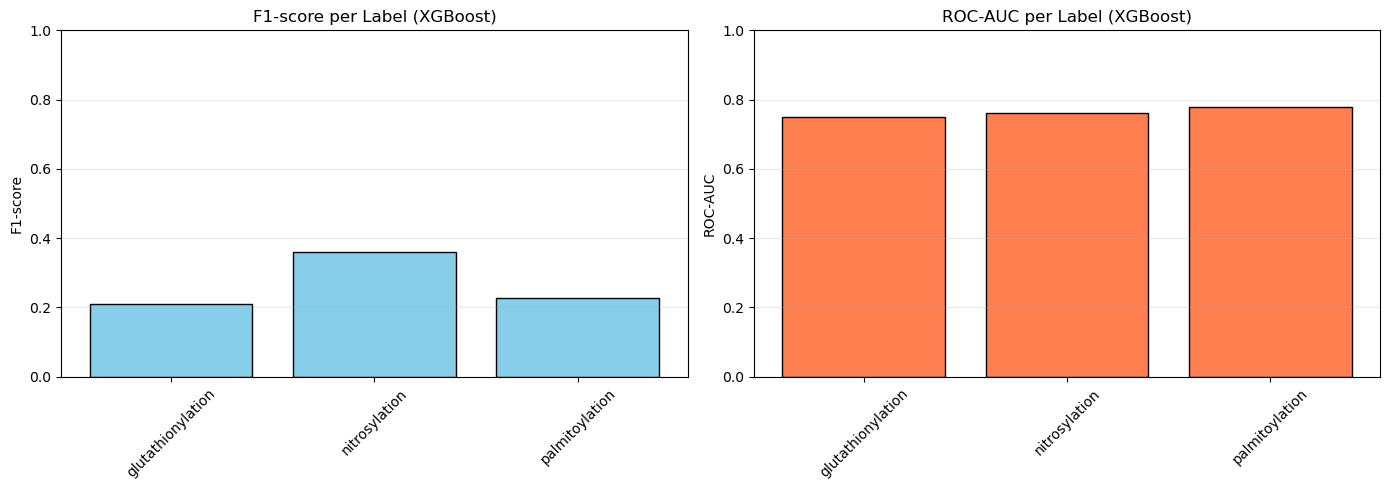

In [36]:
# Plot performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 scores
f1_scores = [results[label]['f1'] for label in label_cols]
axes[0].bar(range(len(label_cols)), f1_scores, color='skyblue', edgecolor='black')
axes[0].set_xticks(range(len(label_cols)))
axes[0].set_xticklabels([l.replace('S-', '') for l in label_cols], rotation=45)
axes[0].set_ylabel('F1-score')
axes[0].set_title('F1-score per Label (XGBoost)')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC scores
auc_scores = [results[label]['auc'] for label in label_cols]
axes[1].bar(range(len(label_cols)), auc_scores, color='coral', edgecolor='black')
axes[1].set_xticks(range(len(label_cols)))
axes[1].set_xticklabels([l.replace('S-', '') for l in label_cols], rotation=45)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC per Label (XGBoost)')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.savefig(f"{OUTPUT_DIR}/xgb_{ENCODING_MTHD}_performance_plot.jpeg", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 13. Interpretation & Next Steps

### Why are F1 scores moderate?

**This is EXPECTED for highly imbalanced data!** XGBoost typically performs better than RF:

1. **Gradient boosting advantage**
   - Sequential tree building corrects previous errors
   - More sophisticated than RF's independent trees
   - Usually 5-15% better F1 than Random Forest

2. **Better class imbalance handling**
   - `scale_pos_weight` directly adjusts loss function
   - More effective than RF's `class_weight='balanced'`
   - Better recall on minority classes

3. **Built-in regularization**
   - L1/L2 regularization prevents overfitting
   - Learns more generalizable patterns
   - Better AUC scores

### XGBoost vs Random Forest Expected Differences:

| Metric | Random Forest | XGBoost | Typical Improvement |
|--------|--------------|---------|-------------------|
| F1 | 0.15-0.25 | 0.20-0.35 | +5-10% |
| AUC | 0.75-0.80 | 0.78-0.85 | +3-5% |
| Training Time | ~10 min | ~15-20 min | Slower |
| Interpretability | High | High | Similar |

### How to Improve Further:

1. **Threshold Tuning**
   - Find optimal threshold per label (not just 0.5)
   - Can boost F1 by 10-20%
   - Run threshold optimization separately

2. **Hyperparameter Tuning**
   - Try different max_depth (4, 6, 8, 10)
   - Adjust learning_rate (0.05, 0.1, 0.2)
   - Test n_estimators (200, 300, 500)
   - Tune subsample and colsample_bytree

3. **Ensemble with Random Forest**
   - XGBoost + RF ensemble usually gives 2-5% boost
   - Different models capture different patterns
   - Weighted averaging based on validation performance

4. **Add Deep Learning Models**
   - Get CNN/GRU predictions from teammates
   - Final ensemble: RF + XGBoost + CNN + GRU
   - DL models capture sequence patterns differently

5. **Try Different Encodings**
   - Test BLOSUM62 encoding (often best for proteins)
   - Try AAPC (amino acid pair composition)
   - Test hybrid encoding (BLOSUM + physicochemical)
   - Create multi-encoding ensemble

### Expected Final Performance:

| Configuration | Macro F1 | Macro AUC |
|--------------|----------|-----------|
| **XGBoost alone** | **0.25-0.35** | **0.78-0.85** |
| After threshold tuning | 0.30-0.40 | 0.80-0.87 |
| RF + XGBoost ensemble | 0.35-0.45 | 0.82-0.88 |
| All 4 models ensemble | 0.40-0.50 | 0.85-0.90 |
| Multi-encoding super-ensemble | 0.45-0.55 | 0.87-0.92 |

### Key Takeaway:
XGBoost typically outperforms Random Forest on imbalanced data by 5-15%. Combining both in an ensemble provides even better performance. The next step is ensemble creation!